### Projet : Prédiction de la qualité de l'air dans les villes marocaines
# Étape 2 : Préparation des données
On va :
1. Charger et explorer le dataset brut
2. Nettoyer les données (doublons, valeurs manquantes)
3. Extraire des nouvelles features depuis le timestamp
4. Encoder les variables catégorielles (ville, description_meteo)
5. Définir X (features) et y (target = PM2.5)
6. Normaliser les features numériques
7. Sauvegarder le dataset propre prêt pour la modélisation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("Bibliothèques importées avec succès !")

Bibliothèques importées avec succès !


## 1. Chargement et exploration initiale

In [4]:

df = pd.read_csv("data_raw.csv")

print("=" * 45)
print(f"Nombre de lignes    : {len(df)}")
print(f"Nombre de colonnes  : {len(df.columns)}")
print(f"Villes présentes    : {df['ville'].unique().tolist()}")
print("=" * 45)
print()
print("Aperçu des premières lignes :")
df.head(6)

Nombre de lignes    : 212
Nombre de colonnes  : 23
Villes présentes    : ['Casablanca', 'Rabat', 'Marrakech', 'Fes']

Aperçu des premières lignes :


,ville,timestamp,latitude,longitude,temperature,temp_ressentie,temp_min,temp_max,humidite,pression,...,description_meteo,visibilite,aqi,aqi_label,pm2_5,pm10,no2,o3,co,so2
0,Casablanca,2026-05-08 19:38:25,33.5928,-7.6192,19.13,18.74,19.07,19.19,63,1011,...,ciel dégagé,10000,3,Modéré,1.17,4.97,0.69,103.43,106.44,1.34
1,Rabat,2026-05-08 19:38:28,33.9911,-6.8401,19.04,18.64,19.04,19.04,63,1010,...,nuageux,8000,3,Modéré,3.90,8.93,2.13,104.25,105.58,4.22
2,Marrakech,2026-05-08 19:38:31,31.6315,-8.0083,22.04,21.50,22.04,22.04,46,1011,...,ciel dégagé,10000,3,Modéré,2.37,8.36,1.31,101.15,103.67,1.15
3,Fes,2026-05-08 19:38:34,34.0372,-4.9998,23.14,22.79,23.14,23.14,49,1008,...,nuageux,10000,2,Correct,4.99,10.49,0.95,90.74,98.58,0.75
4,Casablanca,2026-05-08 19:39:51,33.5928,-7.6192,19.13,18.74,19.07,19.19,63,1011,...,ciel dégagé,10000,3,Modéré,1.17,4.97,0.69,103.43,106.44,1.34
5,Rabat,2026-05-08 19:39:54,33.9911,-6.8401,19.04,18.64,19.04,19.04,63,1010,...,nuageux,8000,3,Modéré,3.90,8.93,2.13,104.25,105.58,4.22


In [5]:
# Infos générales sur les types et valeurs manquantes
print("INFORMATIONS DU DATASET")
print("=" * 45)
df.info()

INFORMATIONS DU DATASET
<class 'pandas.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ville              212 non-null    str    
 1   timestamp          212 non-null    str    
 2   latitude           212 non-null    float64
 3   longitude          212 non-null    float64
 4   temperature        212 non-null    float64
 5   temp_ressentie     212 non-null    float64
 6   temp_min           212 non-null    float64
 7   temp_max           212 non-null    float64
 8   humidite           212 non-null    int64  
 9   pression           212 non-null    int64  
 10  vent_vitesse       212 non-null    float64
 11  vent_direction     212 non-null    int64  
 12  nuages             212 non-null    int64  
 13  description_meteo  212 non-null    str    
 14  visibilite         212 non-null    int64  
 15  aqi                212 non-null    int64  
 16  aqi_label    

In [6]:
print("STATISTIQUES DESCRIPTIVES")
df.describe().round(2)

STATISTIQUES DESCRIPTIVES


,latitude,longitude,temperature,temp_ressentie,temp_min,temp_max,humidite,pression,vent_vitesse,vent_direction,nuages,visibilite,aqi,pm2_5,pm10,no2,o3,co,so2
count,212.00,212.00,212.00,212.00,212.00,212.00,212.00,212.00,212.00,212.00,212.00,212.00,212.00,212.00,212.00,212.00,212.00,212.00,212.00
mean,33.31,-6.87,19.58,19.21,19.51,19.77,61.69,1015.94,3.32,225.71,43.73,8811.32,2.25,2.91,8.41,1.16,91.52,101.94,1.63
std,0.99,1.16,3.11,3.07,3.16,3.19,16.00,2.81,1.47,124.79,31.66,1731.30,0.46,1.42,3.65,0.85,12.15,6.04,1.45
min,31.63,-8.01,11.04,10.81,11.04,11.04,28.00,1008.00,0.00,0.00,0.00,4000.00,1.00,0.68,1.60,0.11,57.44,88.64,0.10
25%,33.10,-7.72,17.04,16.94,17.04,17.19,49.00,1014.00,2.57,197.50,13.00,8000.00,2.00,1.75,5.64,0.36,84.81,97.98,0.55
50%,33.79,-7.23,19.13,18.76,19.07,19.19,63.00,1016.00,3.09,280.00,40.00,10000.00,2.00,2.60,7.89,1.04,92.84,102.22,1.00
75%,34.00,-6.38,22.04,21.50,22.04,22.04,72.00,1018.00,4.12,310.00,75.00,10000.00,3.00,3.82,10.89,1.77,100.34,106.18,2.56
max,34.04,-5.00,28.04,27.22,28.04,28.04,100.00,1022.00,7.72,360.00,100.00,10000.00,3.00,6.97,18.97,3.93,121.17,114.53,6.43


## 2. Nettoyage des données

In [7]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print()
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons : {nb_doublons}")
if nb_doublons > 0:
    df = df.drop_duplicates()
    print(f"  --> Doublons supprimés. Nouvelles lignes : {len(df)}")
else:
    print("  --> Aucun doublon détecté. Dataset propre !")

Valeurs manquantes par colonne :
ville                0
timestamp            0
latitude             0
longitude            0
temperature          0
temp_ressentie       0
temp_min             0
temp_max             0
humidite             0
pression             0
vent_vitesse         0
vent_direction       0
nuages               0
description_meteo    0
visibilite           0
aqi                  0
aqi_label            0
pm2_5                0
pm10                 0
no2                  0
o3                   0
co                   0
so2                  0
dtype: int64

Nombre de doublons : 0
  --> Aucun doublon détecté. Dataset propre !


Distribution de PM2.5 :
count    212.000
mean       2.910
std        1.422
min        0.680
25%        1.750
50%        2.600
75%        3.818
max        6.970
Name: pm2_5, dtype: float64



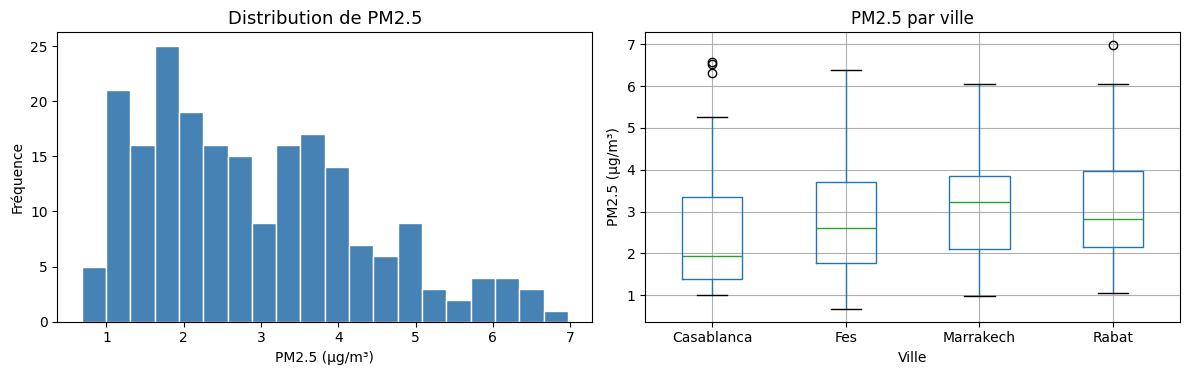

Graphique sauvegardé : distribution_pm25.png


In [8]:
# --- Vérification des valeurs aberrantes sur PM2.5 ---
print("Distribution de PM2.5 :")
print(df['pm2_5'].describe().round(3))
print()

# Visualisation de la distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['pm2_5'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution de PM2.5', fontsize=13)
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Fréquence')

# Box plot par ville
df.boxplot(column='pm2_5', by='ville', ax=axes[1])
axes[1].set_title('PM2.5 par ville')
axes[1].set_xlabel('Ville')
axes[1].set_ylabel('PM2.5 (µg/m³)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('distribution_pm25.png', dpi=120, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : distribution_pm25.png")

## 3. Extraction de features depuis le timestamp

In [9]:
# Convertir le timestamp en datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extraire de nouvelles features temporelles
df['heure']          = df['timestamp'].dt.hour
df['jour_semaine']   = df['timestamp'].dt.dayofweek   # 0=Lundi, 6=Dimanche
df['jour_mois']      = df['timestamp'].dt.day

print("Nouvelles colonnes temporelles créées :")
print(df[['timestamp', 'heure', 'jour_semaine', 'jour_mois']].head(8))

Nouvelles colonnes temporelles créées :
            timestamp  heure  jour_semaine  jour_mois
0 2026-05-08 19:38:25     19             4          8
1 2026-05-08 19:38:28     19             4          8
2 2026-05-08 19:38:31     19             4          8
3 2026-05-08 19:38:34     19             4          8
4 2026-05-08 19:39:51     19             4          8
5 2026-05-08 19:39:54     19             4          8
6 2026-05-08 19:39:56     19             4          8
7 2026-05-08 19:39:58     19             4          8


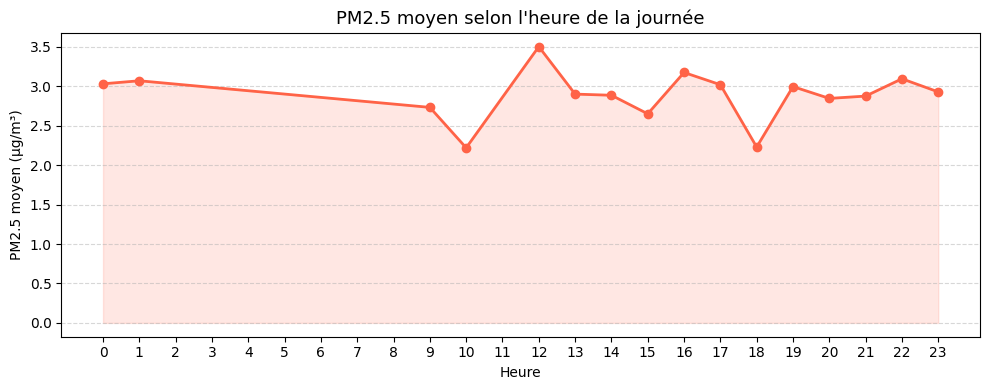

Graphique sauvegardé : pm25_par_heure.png


In [10]:
# Visualiser PM2.5 selon l'heure de la journée
pm25_par_heure = df.groupby('heure')['pm2_5'].mean()

plt.figure(figsize=(10, 4))
plt.plot(pm25_par_heure.index, pm25_par_heure.values, marker='o', color='tomato', linewidth=2)
plt.fill_between(pm25_par_heure.index, pm25_par_heure.values, alpha=0.15, color='tomato')
plt.title('PM2.5 moyen selon l\'heure de la journée', fontsize=13)
plt.xlabel('Heure')
plt.ylabel('PM2.5 moyen (µg/m³)')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('pm25_par_heure.png', dpi=120, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : pm25_par_heure.png")

## 4. Encodage des variables catégorielles

In [11]:

le_ville = LabelEncoder()
df['ville_encoded'] = le_ville.fit_transform(df['ville'])

print("Encodage de la colonne 'ville' :")
for nom, code_num in zip(le_ville.classes_, le_ville.transform(le_ville.classes_)):
    print(f"  {nom} --> {code_num}")
print()

le_meteo = LabelEncoder()
df['meteo_encoded'] = le_meteo.fit_transform(df['description_meteo'])

print("Encodage de la colonne 'description_meteo' :")
for nom, code_num in zip(le_meteo.classes_, le_meteo.transform(le_meteo.classes_)):
    print(f"  {nom} --> {code_num}")

Encodage de la colonne 'ville' :
  Casablanca --> 0
  Fes --> 1
  Marrakech --> 2
  Rabat --> 3

Encodage de la colonne 'description_meteo' :
  ciel dégagé --> 0
  couvert --> 1
  légère pluie --> 2
  nuageux --> 3
  partiellement nuageux --> 4
  peu nuageux --> 5
  poussière --> 6


In [12]:
# Vérification après encodage
print("Aperçu avec les colonnes encodées :")
df[['ville', 'ville_encoded', 'description_meteo', 'meteo_encoded']].drop_duplicates().head(10)

Aperçu avec les colonnes encodées :


,ville,ville_encoded,description_meteo,meteo_encoded
0,Casablanca,0,ciel dégagé,0
1,Rabat,3,nuageux,3
2,Marrakech,2,ciel dégagé,0
3,Fes,1,nuageux,3
8,Casablanca,0,nuageux,3
12,Casablanca,0,couvert,1
14,Marrakech,2,partiellement nuageux,4
15,Fes,1,partiellement nuageux,4
22,Marrakech,2,nuageux,3
23,Fes,1,peu nuageux,5


## 5. Sélection des features et de la variable cible

In [13]:
# Colonnes à exclure (non-features)
COLONNES_A_EXCLURE = [
    'ville',              
    'timestamp',          # remplacée par heure, jour_semaine, jour_mois
    'description_meteo',  # remplacée par meteo_encoded
    'aqi_label',          
    'latitude',          
    'longitude',
    'pm2_5',              
    'aqi',                
]

# Définir X (features) et y (target)
FEATURES = [col for col in df.columns if col not in COLONNES_A_EXCLURE]
TARGET   = 'pm2_5'

X = df[FEATURES]
y = df[TARGET]

print(f"Variable cible (y)   : {TARGET}")
print(f"Nombre de features   : {len(FEATURES)}")
print(f"Features sélectionnées :")
for f in FEATURES:
    print(f"  - {f}")

Variable cible (y)   : pm2_5
Nombre de features   : 20
Features sélectionnées :
  - temperature
  - temp_ressentie
  - temp_min
  - temp_max
  - humidite
  - pression
  - vent_vitesse
  - vent_direction
  - nuages
  - visibilite
  - pm10
  - no2
  - o3
  - co
  - so2
  - heure
  - jour_semaine
  - jour_mois
  - ville_encoded
  - meteo_encoded


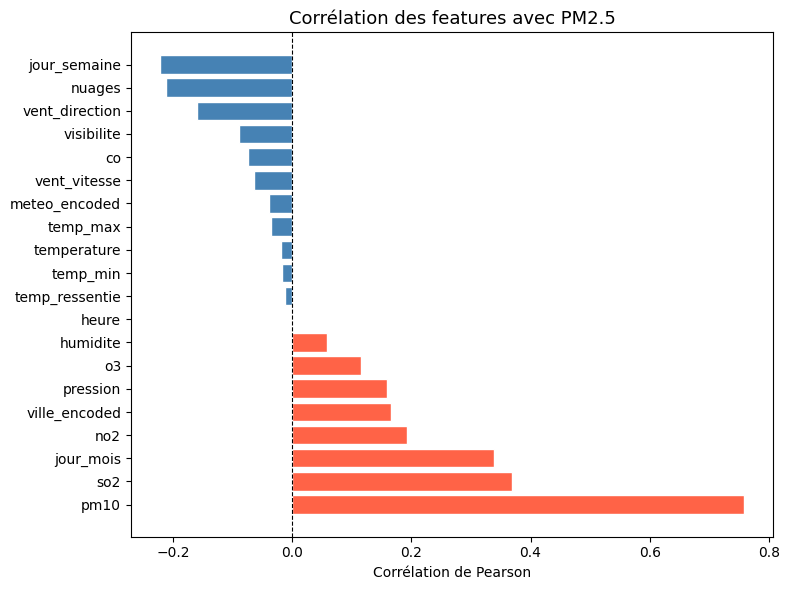

Graphique sauvegardé : correlation_pm25.png


In [14]:
# Matrice de corrélation avec PM2.5
correlation = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in correlation.values]
bars = plt.barh(correlation.index, correlation.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Corrélation des features avec PM2.5', fontsize=13)
plt.xlabel('Corrélation de Pearson')
plt.tight_layout()
plt.savefig('correlation_pm25.png', dpi=120, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : correlation_pm25.png")

## 6. Normalisation des features numériques


In [15]:
# Normaliser avec StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES)

print("Features normalisées (5 premières lignes) :")
print(X_scaled.head().round(3))
print()
print("Vérification — Moyenne de chaque colonne (doit être ~0) :")
print(X_scaled.mean().round(6))
print()
print("Vérification — Écart-type de chaque colonne (doit être ~1) :")
print(X_scaled.std().round(6))

Features normalisées (5 premières lignes) :
   temperature  temp_ressentie  temp_min  temp_max  humidite  pression  \
0       -0.144          -0.152    -0.139    -0.182     0.082    -1.765   
1       -0.173          -0.184    -0.148    -0.229     0.082    -2.122   
2        0.794           0.749     0.803     0.714    -0.983    -1.765   
3        1.149           1.171     1.152     1.060    -0.795    -2.837   
4       -0.144          -0.152    -0.139    -0.182     0.082    -1.765   

   vent_vitesse  vent_direction  nuages  visibilite   pm10    no2     o3  \
0         0.546           0.597  -1.384       0.688 -0.945 -0.550  0.982   
1        -0.854           0.757   0.990      -0.470  0.141  1.148  1.050   
2         2.293           0.516  -1.384       0.688 -0.015  0.181  0.794   
3        -0.154           0.918   0.990       0.688  0.569 -0.243 -0.065   
4         0.546           0.597  -1.384       0.688 -0.945 -0.550  0.982   

      co    so2  heure  jour_semaine  jour_mois  ville

## 7. Sauvegarde du dataset propre

In [16]:
# Sauvegarder le dataset propre 
df_clean = X_scaled.copy()
df_clean['pm2_5'] = y.values
df_clean['ville'] = df['ville'].values   

df_clean.to_csv("Data/data_clean.csv", index=False)

print("Dataset propre sauvegardé : data_clean.csv")
print(f"  Lignes   : {len(df_clean)}")
print(f"  Colonnes : {len(df_clean.columns)}")
print()
print("Aperçu final :")
df_clean.head()

Dataset propre sauvegardé : data_clean.csv
  Lignes   : 212
  Colonnes : 22

Aperçu final :


,temperature,temp_ressentie,temp_min,temp_max,humidite,pression,vent_vitesse,vent_direction,nuages,visibilite,...,o3,co,so2,heure,jour_semaine,jour_mois,ville_encoded,meteo_encoded,pm2_5,ville
0,-0.144085,-0.151831,-0.138718,-0.182150,0.081843,-1.764811,0.546072,0.596750,-1.384332,0.688206,...,0.982053,0.746437,-0.199406,0.427703,0.113895,-1.309903,-1.341641,-1.524141,1.17,Casablanca
1,-0.173112,-0.184483,-0.148235,-0.229339,0.081843,-2.122156,-0.853873,0.757399,0.989832,-0.469728,...,1.049681,0.603671,1.797137,0.427703,0.113895,-1.309903,1.341641,0.231934,3.90,Rabat
2,0.794455,0.749359,0.803487,0.714429,-0.983003,-1.764811,2.292607,0.516426,-1.384332,0.688206,...,0.794014,0.286597,-0.331122,0.427703,0.113895,-1.309903,0.447214,-1.524141,2.37,Marrakech
3,1.149230,1.170567,1.152452,1.060478,-0.795089,-2.836845,-0.153900,0.918048,0.989832,0.688206,...,-0.064531,-0.558379,-0.608420,0.427703,0.113895,-1.309903,-0.447214,0.231934,4.99,Fes
4,-0.144085,-0.151831,-0.138718,-0.182150,0.081843,-1.764811,0.546072,0.596750,-1.384332,0.688206,...,0.982053,0.746437,-0.199406,0.427703,0.113895,-1.309903,-1.341641,-1.524141,1.17,Casablanca


In [17]:
# Résumé complet de ce qu'on a fait
print("=" * 50)
print("   RÉSUMÉ DE L'ÉTAPE 2 — PRÉPARATION")
print("=" * 50)
print(f"  Données brutes         : {len(df)} lignes")
print(f"  Doublons supprimés     : {df.duplicated().sum()}")
print(f"  Valeurs manquantes     : {df.isnull().sum().sum()}")
print(f"  Features créées        : {len(FEATURES)}")
print(f"  Variable cible         : pm2_5 (régression)")
print(f"  Normalisation          : StandardScaler")
print(f"  Fichier de sortie      : data_clean.csv")
print("=" * 50)
print()
print("Prêt pour l'Étape 3 : Modélisation !")

   RÉSUMÉ DE L'ÉTAPE 2 — PRÉPARATION
  Données brutes         : 212 lignes
  Doublons supprimés     : 0
  Valeurs manquantes     : 0
  Features créées        : 20
  Variable cible         : pm2_5 (régression)
  Normalisation          : StandardScaler
  Fichier de sortie      : data_clean.csv

Prêt pour l'Étape 3 : Modélisation !
